<a href="https://colab.research.google.com/github/shrouqNahar/AI-Enhanced-Provenance-Forensics-for-Deepfake-Detection-across-Social-IoT-Networks/blob/main/Model_Train_notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kshitizbhargava/deepfake-face-images")

print("Path to dataset files:", path)

100%|██████████| 244M/244M [00:16<00:00, 15.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kshitizbhargava/deepfake-face-images/versions/1


In [ ]:
import os
import shutil


target_base = "/content/Dataset"
if os.path.exists(target_base):
    shutil.rmtree(target_base)

if os.path.isdir(os.path.join(path, "Fake")) and os.path.isdir(os.path.join(path, "Real")):
    shutil.copytree(path, target_base)
else:

    found = False
    for root, dirs, files in os.walk(path):
        if "Fake" in dirs and "Real" in dirs:
            shutil.copytree(root, target_base)
            found = True
            break
    if not found:
        raise Exception("Could not find 'Fake' and 'Real' folders in the downloaded dataset. Please check the dataset structure.")

print("Dataset copied to /content/Dataset")
!ls /content/Dataset

Dataset copied to /content/Dataset
dataset.csv  Fake  Real


In [ ]:
!pip install timm

import os
import json
import hashlib
import random
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from google.colab import drive

In [ ]:
DATASET_PATH = "/content/Dataset"

print("Contents of dataset root:", os.listdir(DATASET_PATH))
if not os.path.isdir(os.path.join(DATASET_PATH, "Fake")) or not os.path.isdir(os.path.join(DATASET_PATH, "Real")):
    raise Exception("Dataset does not contain 'Fake' and 'Real' folders.")

if not (os.path.isdir(os.path.join(DATASET_PATH, "Train")) and os.path.isdir(os.path.join(DATASET_PATH, "Validation")) and os.path.isdir(os.path.join(DATASET_PATH, "Test"))):
    print("Predefined splits not found. Creating train/val/test splits with 70/15/15 ratio...")

    for split in ["Train", "Validation", "Test"]:
        for label in ["Fake", "Real"]:
            os.makedirs(os.path.join(DATASET_PATH, split, label), exist_ok=True)

    fake_images = [os.path.join(DATASET_PATH, "Fake", f) for f in os.listdir(os.path.join(DATASET_PATH, "Fake")) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    real_images = [os.path.join(DATASET_PATH, "Real", f) for f in os.listdir(os.path.join(DATASET_PATH, "Real")) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    fake_train, fake_temp = train_test_split(fake_images, test_size=0.3, random_state=42)
    fake_val, fake_test = train_test_split(fake_temp, test_size=0.5, random_state=42)

    real_train, real_temp = train_test_split(real_images, test_size=0.3, random_state=42)
    real_val, real_test = train_test_split(real_temp, test_size=0.5, random_state=42)

    for img in fake_train:
        shutil.copy(img, os.path.join(DATASET_PATH, "Train", "Fake", os.path.basename(img)))
    for img in fake_val:
        shutil.copy(img, os.path.join(DATASET_PATH, "Validation", "Fake", os.path.basename(img)))
    for img in fake_test:
        shutil.copy(img, os.path.join(DATASET_PATH, "Test", "Fake", os.path.basename(img)))

    for img in real_train:
        shutil.copy(img, os.path.join(DATASET_PATH, "Train", "Real", os.path.basename(img)))
    for img in real_val:
        shutil.copy(img, os.path.join(DATASET_PATH, "Validation", "Real", os.path.basename(img)))
    for img in real_test:
        shutil.copy(img, os.path.join(DATASET_PATH, "Test", "Real", os.path.basename(img)))

    print("Splits created successfully.")
else:
    print("Using existing train/val/test splits.")

Contents of dataset root: ['Fake', 'Real', 'dataset.csv']
Predefined splits not found. Creating train/val/test splits with 70/15/15 ratio...
Splits created successfully.


In [ ]:
def compute_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.sha256(f.read()).hexdigest()

def generate_metadata(image_path):
    metadata = {
        "hash": compute_hash(image_path),
        "timestamp": datetime.now().isoformat(),
        "device_id": hashlib.sha256(b"device_01").hexdigest()[:16]
    }
    with open(image_path + ".json", "w") as f:
        json.dump(metadata, f)

for split in ["Train", "Validation", "Test"]:
    for label in ["Fake", "Real"]:
        folder = os.path.join(DATASET_PATH, split, label)
        for file in os.listdir(folder):
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                generate_metadata(os.path.join(folder, file))

print("Provenance metadata created.")

Provenance metadata created.


In [ ]:
def remove_random_metadata(folder, percentage=0.2):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    remove_count = int(len(files) * percentage)
    for f in random.sample(files, remove_count):
        os.remove(os.path.join(folder, f))

def forge_random_metadata(folder, percentage=0.1):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    forge_count = int(len(files) * percentage)
    for f in random.sample(files, forge_count):
        path = os.path.join(folder, f)
        with open(path, "r") as file:
            metadata = json.load(file)
        metadata["hash"] = "FORGED_HASH"
        with open(path, "w") as file:
            json.dump(metadata, file)

for label in ["Fake", "Real"]:
    folder = os.path.join(DATASET_PATH, "Test", label)
    remove_random_metadata(folder, 0.2)
    forge_random_metadata(folder, 0.1)

print("Provenance manipulation simulated.")

Provenance manipulation simulated.


In [ ]:
def verify_provenance(image_path):
    metadata_path = image_path + ".json"

    if not os.path.exists(metadata_path):
        return "missing"

    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    if metadata["hash"] != compute_hash(image_path):
        return "forged"

    return "valid"

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 2

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Validation"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [ ]:
from tqdm import tqdm

EPOCHS = 4

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/4]: 100%|██████████| 4512/4512 [03:09<00:00, 23.85it/s, loss=0.161]


Epoch 1 Loss: 0.1551


Epoch [2/4]: 100%|██████████| 4512/4512 [03:04<00:00, 24.47it/s, loss=0.000418]


Epoch 2 Loss: 0.0799


Epoch [3/4]: 100%|██████████| 4512/4512 [03:03<00:00, 24.59it/s, loss=0.000103]


Epoch 3 Loss: 0.0622


Epoch [4/4]: 100%|██████████| 4512/4512 [03:06<00:00, 24.19it/s, loss=0.000945]

Epoch 4 Loss: 0.0465


In [ ]:
model.eval()

all_probs = []
all_labels = []
all_preds = []
all_paths = []

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:,1]

        for j in range(len(probs)):
            idx = i * BATCH_SIZE + j
            image_path = test_dataset.samples[idx][0]

            provenance_status = verify_provenance(image_path)
            model_score = probs[j].item()

            if provenance_status == "valid":
                adjustment = 0
            elif provenance_status == "missing":
                adjustment = 0.15
            elif provenance_status == "forged":
                adjustment = 0.35

            final_score = min(model_score + adjustment, 1.0)
            prediction = 1 if final_score > 0.5 else 0

            all_probs.append(final_score)
            all_labels.append(labels[j].item())
            all_preds.append(prediction)
            all_paths.append(image_path)

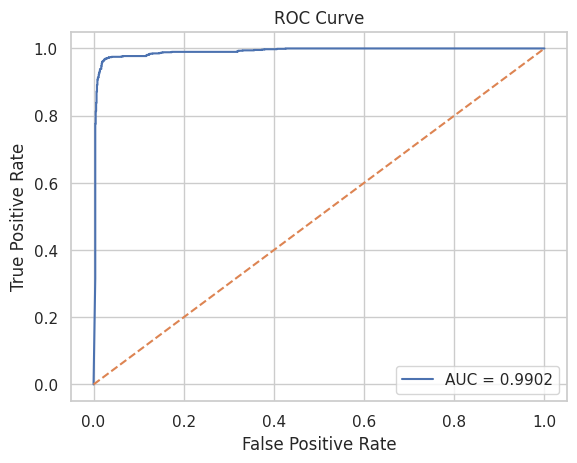

AUC Score: 0.9901842275371686


In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [ ]:
report = classification_report(all_labels, all_preds, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv("classification_report.csv")
df_report

,precision,recall,f1-score,support
0,0.972460,0.975238,0.973847,1050.000000
1,0.970488,0.967195,0.968839,884.000000
accuracy,0.971562,0.971562,0.971562,0.971562
macro avg,0.971474,0.971216,0.971343,1934.000000
weighted avg,0.971558,0.971562,0.971558,1934.000000


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
df_cm = pd.DataFrame(cm,
                     columns=["Pred Real", "Pred Fake"],
                     index=["Actual Real", "Actual Fake"])
df_cm.to_csv("confusion_matrix.csv")
df_cm

,Pred Real,Pred Fake
Actual Real,1024,26
Actual Fake,29,855


In [ ]:
results_df = pd.DataFrame({
    "Image_Path": all_paths,
    "True_Label": all_labels,
    "Predicted_Label": all_preds,
    "Hybrid_Score": all_probs
})

results_df.to_csv("detailed_results.csv")
results_df.head()

,Image_Path,True_Label,Predicted_Label,Hybrid_Score
0,/content/Dataset/Test/Fake/00B4R41FLE.jpg,0,0,0.196177
1,/content/Dataset/Test/Fake/00S2D5CDKQ.jpg,0,0,0.013320
2,/content/Dataset/Test/Fake/01AV0VOUAX.jpg,0,0,0.015610
3,/content/Dataset/Test/Fake/01HUIAWIOM.jpg,0,0,0.152852
4,/content/Dataset/Test/Fake/01HYNP6M67.jpg,0,0,0.151226


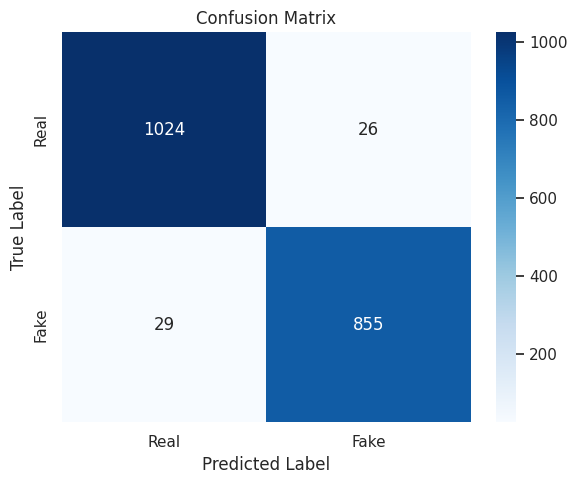

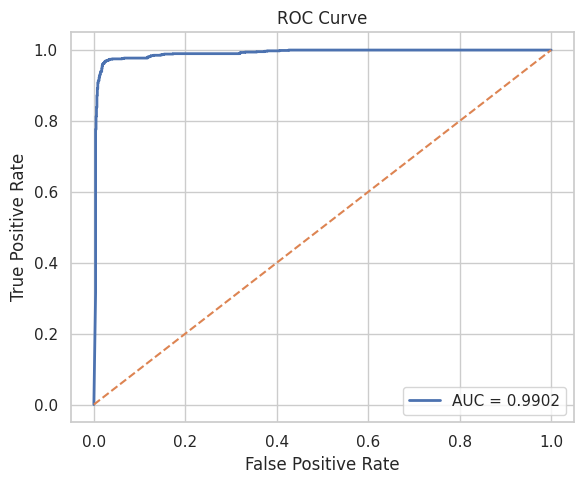

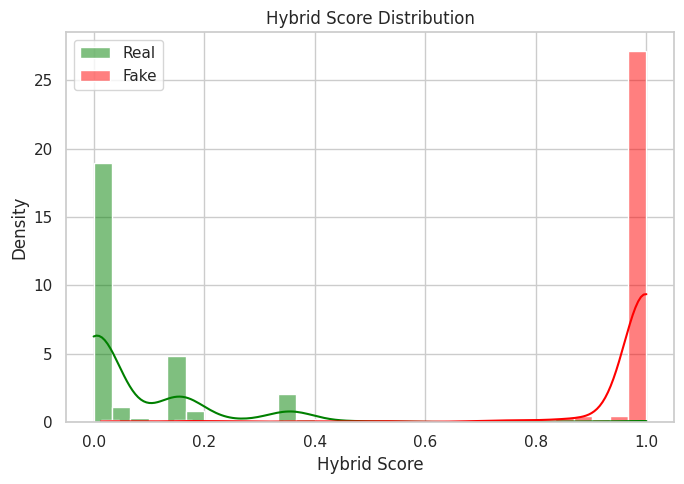

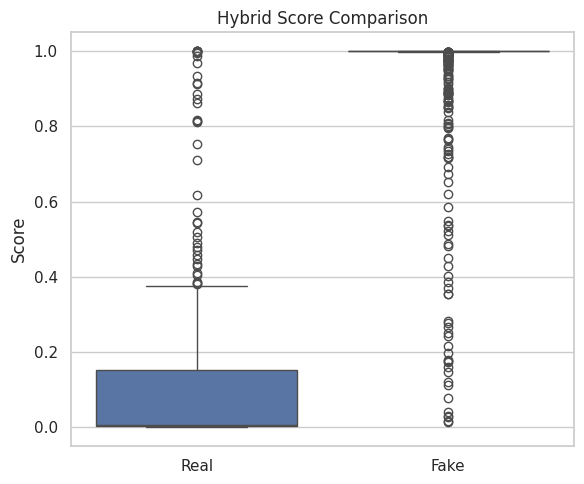


FINAL PERFORMANCE SUMMARY
Accuracy: 0.9716
AUC Score: 0.9902
Total Samples: 1934


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

sns.set_theme(style="whitegrid")


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_visual.png", dpi=300)
plt.show()




fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_visual.png", dpi=300)
plt.show()




real_scores = [all_probs[i] for i in range(len(all_labels)) if all_labels[i] == 0]
fake_scores = [all_probs[i] for i in range(len(all_labels)) if all_labels[i] == 1]

plt.figure(figsize=(7,5))
sns.histplot(real_scores, color="green", label="Real", kde=True, stat="density", bins=30)
sns.histplot(fake_scores, color="red", label="Fake", kde=True, stat="density", bins=30)
plt.legend()
plt.title("Hybrid Score Distribution")
plt.xlabel("Hybrid Score")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=300)
plt.show()




plt.figure(figsize=(6,5))
sns.boxplot(data=[real_scores, fake_scores])
plt.xticks([0,1], ["Real", "Fake"])
plt.title("Hybrid Score Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("score_boxplot.png", dpi=300)
plt.show()




accuracy = np.mean(np.array(all_labels) == np.array(all_preds))

print("\n====================================")
print("FINAL PERFORMANCE SUMMARY")
print("====================================")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {roc_auc:.4f}")
print(f"Total Samples: {len(all_labels)}")
print("====================================")



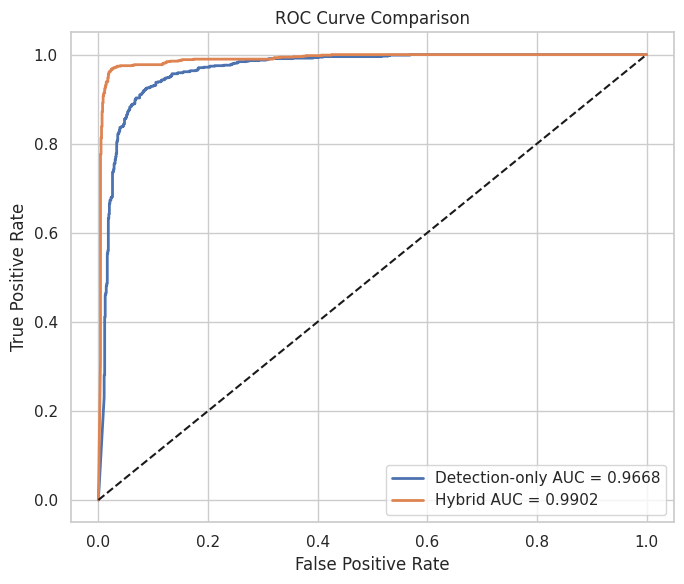

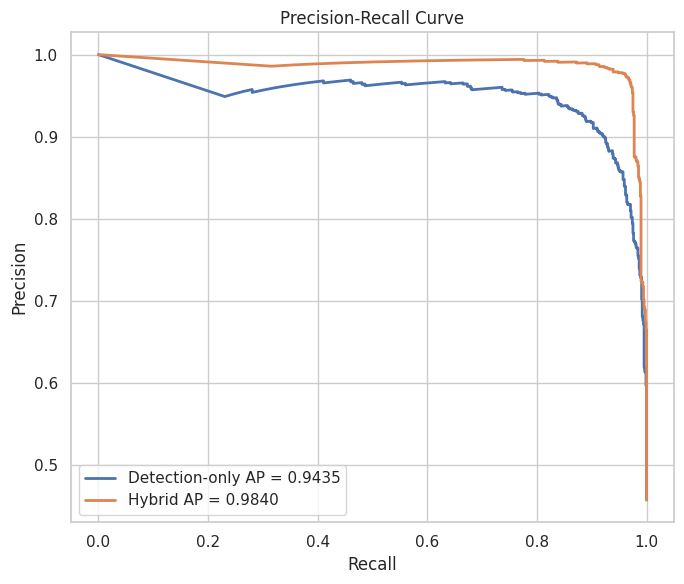


DETECTION vs HYBRID COMPARISON
Detection-only AUC: 0.9668
Hybrid AUC:         0.9902
--------------------------------------
Detection-only AP:  0.9435
Hybrid AP:          0.9840
--------------------------------------
Paired t-test statistic: 8.4473
p-value: 0.000000
Result: Statistically significant improvement (p < 0.05)


In [ ]:


import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)
from scipy.stats import ttest_rel

sns.set_theme(style="whitegrid")


try:
    model_probs
except NameError:
    model_probs = all_probs.copy()



fpr_model, tpr_model, _ = roc_curve(all_labels, model_probs)
auc_model = auc(fpr_model, tpr_model)

fpr_hybrid, tpr_hybrid, _ = roc_curve(all_labels, all_probs)
auc_hybrid = auc(fpr_hybrid, tpr_hybrid)

plt.figure(figsize=(7,6))
plt.plot(fpr_model, tpr_model, linewidth=2, label=f"Detection-only AUC = {auc_model:.4f}")
plt.plot(fpr_hybrid, tpr_hybrid, linewidth=2, label=f"Hybrid AUC = {auc_hybrid:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_comparison.png")
plt.show()




precision_model, recall_model, _ = precision_recall_curve(all_labels, model_probs)
precision_hybrid, recall_hybrid, _ = precision_recall_curve(all_labels, all_probs)

ap_model = average_precision_score(all_labels, model_probs)
ap_hybrid = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(7,6))
plt.plot(recall_model, precision_model, linewidth=2,
         label=f"Detection-only AP = {ap_model:.4f}")
plt.plot(recall_hybrid, precision_hybrid, linewidth=2,
         label=f"Hybrid AP = {ap_hybrid:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_comparison.png")
plt.show()









t_stat, p_value = ttest_rel(model_probs, all_probs)



print("\n======================================")
print("DETECTION vs HYBRID COMPARISON")
print("======================================")
print(f"Detection-only AUC: {auc_model:.4f}")
print(f"Hybrid AUC:         {auc_hybrid:.4f}")
print("--------------------------------------")
print(f"Detection-only AP:  {ap_model:.4f}")
print(f"Hybrid AP:          {ap_hybrid:.4f}")
print("--------------------------------------")
print(f"Paired t-test statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Statistically significant improvement (p < 0.05)")
else:
    print("Result: No statistically significant difference")

